# Book Recommendation System — 01 Exploratory Data Analysis

A **collaborative-filtering** recommender on the goodbooks-10k dataset. Users rated books **1–5**; we learn from the user × book rating matrix to recommend unread books. No external label — this is self-supervised on the ratings alone.

(A subsample of the 6M-rating original is used: books with ≥50 ratings, users with ≥20, then 4,000 users sampled — to keep the project laptop-friendly.)

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
import utils
ratings=utils.load_ratings(); titles=utils.load_items()
print('ratings:',ratings.shape,'| users:',ratings.user.nunique(),'| books:',ratings.item.nunique())
ratings.head()

ratings: (448098, 3) | users: 4000 | books: 9987


,user,item,rating
0,8,2732,5
1,8,1432,3
2,8,479,4
3,8,3020,5
4,8,6195,4


## 1. Rating distribution

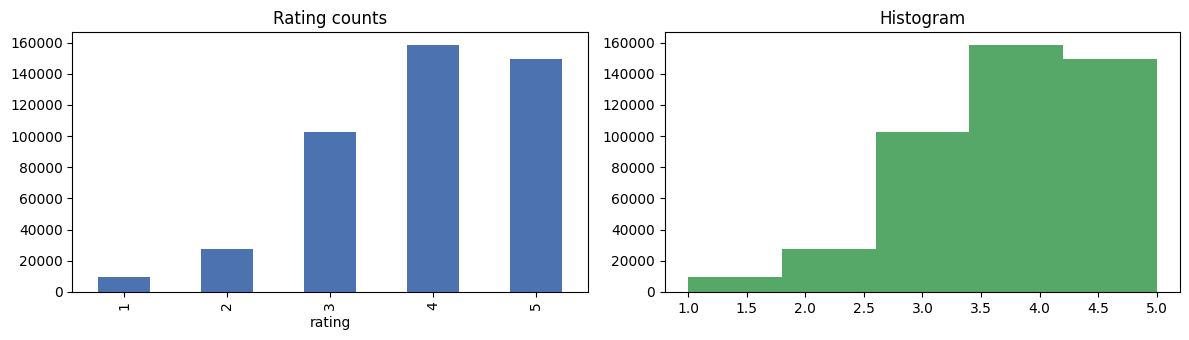

mean rating: 3.918


In [2]:
fig,ax=plt.subplots(1,2,figsize=(12,3.5))
ratings['rating'].value_counts().sort_index().plot(kind='bar',ax=ax[0],color='#4c72b0'); ax[0].set_title('Rating counts'); ax[0].set_xlabel('rating')
ax[1].hist(ratings['rating'],bins=5,color='#55a868'); ax[1].set_title('Histogram')
plt.tight_layout(); plt.show()
print('mean rating:',round(ratings['rating'].mean(),3))

## 2. Activity distributions (long tail)

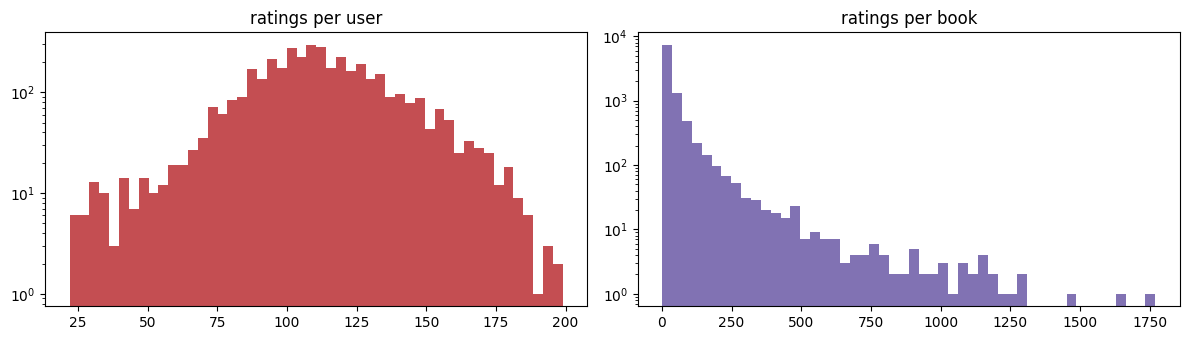

per user: median 111 max 199
per book: median 19 max 1770


In [3]:
rpu=ratings.groupby('user').size(); rpb=ratings.groupby('item').size()
fig,ax=plt.subplots(1,2,figsize=(12,3.5))
ax[0].hist(rpu,bins=50,color='#c44e52'); ax[0].set_title('ratings per user'); ax[0].set_yscale('log')
ax[1].hist(rpb,bins=50,color='#8172b3'); ax[1].set_title('ratings per book'); ax[1].set_yscale('log')
plt.tight_layout(); plt.show()
print('per user: median %d max %d'%(rpu.median(),rpu.max())); print('per book: median %d max %d'%(rpb.median(),rpb.max()))

## 3. Sparsity

In [4]:
nu,ni=ratings.user.nunique(),ratings.item.nunique(); d=len(ratings)/(nu*ni)
print(f'{nu} users x {ni} books = {nu*ni:,} cells; {len(ratings):,} ratings')
print('density: %.3f%% (sparsity %.3f%%)'%(100*d,100*(1-d)))

4000 users x 9987 books = 39,948,000 cells; 448,098 ratings
density: 1.122% (sparsity 98.878%)


## 4. Most-rated & highest-rated books (>=100 ratings)

In [5]:
agg=ratings.groupby('item')['rating'].agg(['mean','count']); agg['title']=agg.index.map(titles)
print('Most-rated:'); print(agg.sort_values('count',ascending=False).head(6)[['title','count','mean']].to_string())
print('\nHighest-rated (>=100):'); print(agg[agg['count']>=100].sort_values('mean',ascending=False).head(6)[['title','count','mean']].to_string())

Most-rated:
                                                         title  count      mean
item                                                                           
1                      The Hunger Games (The Hunger Games, #1)   1770  4.267232
2     Harry Potter and the Sorcerer's Stone (Harry Potter, #1)   1648  4.370146
4                                        To Kill a Mockingbird   1462  4.301642
3                                      Twilight (Twilight, #1)   1295  3.220849
5                                             The Great Gatsby   1282  3.783931
17                        Catching Fire (The Hunger Games, #2)   1266  4.091627

Highest-rated (>=100):
                                                                         title  count      mean
item                                                                                           
780                                                          Calvin and Hobbes    101  4.772277
422                                 

## 5. Summary

- Subsample: **4,000 users, 9,987 books, 448,098 ratings**; matrix **>99% sparse**.
- Ratings skew high (mean ≈ 3.9) — readers mostly rate books they chose to read.
- Heavy long tail in both users and books. Notebooks 02–03 restrict to the 2,000 most-rated books / most-active users and compare CF vs matrix factorization.